# GramArogya AI — Exploratory Data Analysis (Phase 5)

**Goal:** understand the cleaned daily dataset and confirm the demand-forecasting
problem is *realistic* before building any model.

We ask, for each major driver, **"why should this affect patient demand or
resource need?"** and check the data agrees. We also lock in the **leakage-safe
feature list** for Phase 6.

Dataset: `data/demand_resource_daily.csv` (2192 days, 2020-01-01 → 2025-12-31,
68 columns). See `docs/DATA_DICTIONARY.md` for column definitions.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# Find the project root (works whether run from notebooks/ or the repo root).
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

df = pd.read_csv(ROOT / "data" / "demand_resource_daily.csv", parse_dates=["date"])
df["outbreak_type"] = df["outbreak_type"].fillna("None")   # null = no outbreak
df = df.sort_values("date").reset_index(drop=True)

CATS = ["general_opd_arrivals", "fever_infectious_arrivals",
        "maternal_child_arrivals", "trauma_emergency_arrivals"]
print(df.shape)
df[["date", "total_patient_arrivals"] + CATS].head()

(2192, 68)


,date,total_patient_arrivals,general_opd_arrivals,fever_infectious_arrivals,maternal_child_arrivals,trauma_emergency_arrivals
0,2020-01-01,126,93,13,6,14
1,2020-01-02,124,82,19,15,8
2,2020-01-03,110,83,18,5,4
3,2020-01-04,107,70,14,9,14
4,2020-01-05,104,69,20,7,8


In [2]:
df["total_patient_arrivals"].describe().round(1)

count    2192.0
mean      137.8
std        23.3
min        85.0
25%       120.0
50%       133.0
75%       152.0
max       221.0
Name: total_patient_arrivals, dtype: float64

## 1. Demand over time

Plot daily total arrivals with a 30-day moving average to reveal the trend.

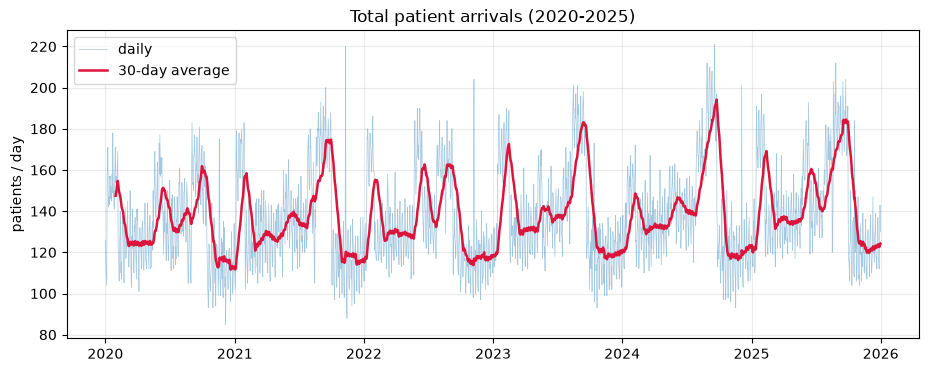

In [3]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["total_patient_arrivals"], lw=0.5, alpha=0.4, label="daily")
ax.plot(df["date"], df["total_patient_arrivals"].rolling(30).mean(),
        color="crimson", lw=1.8, label="30-day average")
ax.set_title("Total patient arrivals (2020-2025)")
ax.set_ylabel("patients / day"); ax.legend(); plt.show()

**Read:** a clear, repeating **annual peak** every year with realistic daily
noise (range ~85-221, mean ~138). The recurring shape means a model can learn
seasonality rather than fitting noise.

## 2. Seasonality — the monsoon effect

Mean arrivals per **month** and per **season**, split by category.

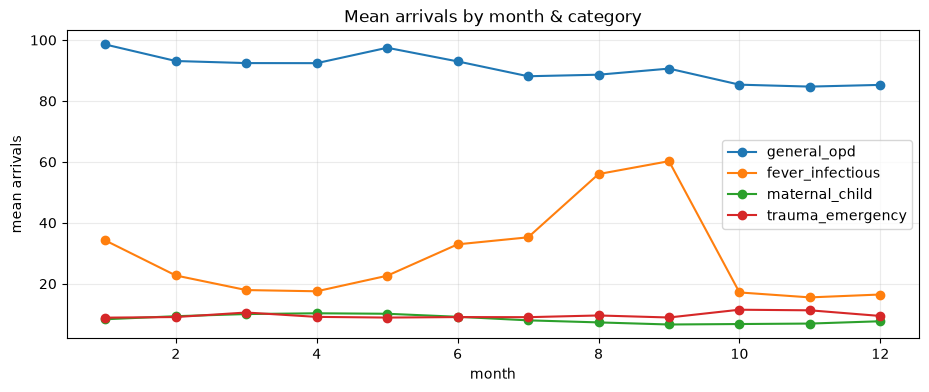

,general_opd_arrivals,fever_infectious_arrivals,maternal_child_arrivals,trauma_emergency_arrivals,total_patient_arrivals
season,,,,,
Winter,92.3,24.5,8.4,9.1,134.3
Summer,94.1,19.4,10.2,9.5,133.2
Monsoon,90.1,46.1,7.8,9.1,153.1
Post_Monsoon,85.0,16.3,6.8,11.4,119.6


In [4]:
by_month = df.groupby("month")[CATS].mean()
fig, ax = plt.subplots()
for c in CATS:
    ax.plot(by_month.index, by_month[c], marker="o", label=c.replace("_arrivals", ""))
ax.set_xlabel("month"); ax.set_ylabel("mean arrivals")
ax.set_title("Mean arrivals by month & category"); ax.legend(); plt.show()

df.groupby("season")[CATS + ["total_patient_arrivals"]].mean() \
  .reindex(["Winter", "Summer", "Monsoon", "Post_Monsoon"]).round(1)

**Read:** **fever/infectious** cases surge in **months 7-9 (monsoon)** — from
~18 to ~60/day (Monsoon mean 46 vs Post-Monsoon 16). This mirrors real
vector/water-borne disease seasonality (dengue, malaria, diarrhoeal). General
OPD is steady; maternal-child and trauma are roughly flat. Monsoon is the main
driver of the annual peak in Section 1.

## 3. Weekly rhythm & event effects

Do market days, festivals, and vaccination camps move demand the way we'd expect?

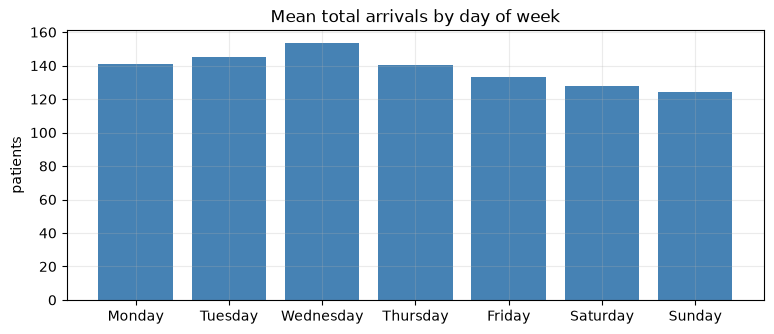

,market_day -> total_opd_load,festival -> trauma,vax_camp -> maternal_child
flag = 0,135.2,9.1,8.2
flag = 1,153.4,19.6,11.1


In [5]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = df.groupby("day_of_week")["total_patient_arrivals"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(dow.index, dow.values, color="steelblue")
ax.set_title("Mean total arrivals by day of week"); ax.set_ylabel("patients"); plt.show()

effects = pd.DataFrame({
    "market_day -> total_opd_load": df.groupby("weekly_market_day")["total_patient_arrivals"].mean(),
    "festival -> trauma":           df.groupby("festival_flag")["trauma_emergency_arrivals"].mean(),
    "vax_camp -> maternal_child":   df.groupby("vaccination_camp_flag")["maternal_child_arrivals"].mean(),
}).round(1)
effects.index = ["flag = 0", "flag = 1"]
effects

**Read:** weekdays (esp. **market day**, ~153 vs 135) are busier than weekends —
rural patients travel on market days. **Festivals roughly double trauma**
(9 → 20; accidents, crowds). **Vaccination camps lift maternal-child** demand
(8 → 11). Every event flag moves the *category it should*.

## 4. What drives demand? (correlations)

Correlation of weather / event / outbreak predictors with each demand category.

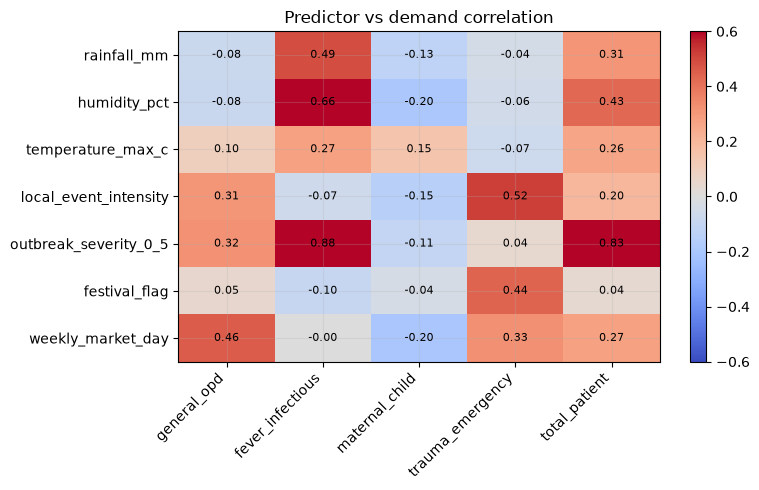

In [6]:
pred = ["rainfall_mm", "humidity_pct", "temperature_max_c", "local_event_intensity",
        "outbreak_severity_0_5", "festival_flag", "weekly_market_day"]
corr = df[pred + CATS + ["total_patient_arrivals"]].corr().loc[pred, CATS + ["total_patient_arrivals"]]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-0.6, vmax=0.6, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels([c.replace("_arrivals", "") for c in corr.columns], rotation=45, ha="right")
ax.set_yticks(range(len(corr.index))); ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); ax.set_title("Predictor vs demand correlation"); plt.tight_layout(); plt.show()

**Read — each driver maps to the right category:**

| Driver | Strongest with | r | Makes sense because |
|---|---|---|---|
| humidity / rainfall | fever_infectious | 0.66 / 0.49 | monsoon → vector/water-borne disease |
| outbreak_severity | fever_infectious / total | 0.88 / 0.83 | outbreaks are mostly infectious |
| local_event_intensity | trauma_emergency | 0.52 | crowds/events → injuries |
| festival_flag | trauma_emergency | 0.44 | festival accidents |
| weekly_market_day | general_opd | 0.46 | travel-day OPD visits |

This is the core evidence that the features are **causally plausible**, not random.

## 5. Outbreak impact by type

How each outbreak type shifts the case mix.

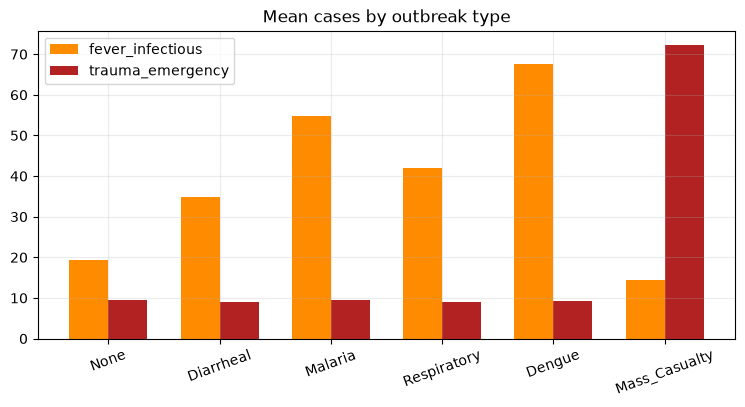

,fever_infectious_arrivals,trauma_emergency_arrivals,total_patient_arrivals
outbreak_type,,,
None,19.4,9.5,125.8
Diarrheal,34.8,8.9,156.9
Malaria,54.7,9.5,158.6
Respiratory,41.9,8.9,164.3
Dengue,67.6,9.2,176.2
Mass_Casualty,14.5,72.2,186.5


In [7]:
ob = df.groupby("outbreak_type")[["fever_infectious_arrivals",
     "trauma_emergency_arrivals", "total_patient_arrivals"]].mean().round(1)
ob = ob.sort_values("total_patient_arrivals")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ob)); w = 0.35
ax.bar(x - w/2, ob["fever_infectious_arrivals"], w, label="fever_infectious", color="darkorange")
ax.bar(x + w/2, ob["trauma_emergency_arrivals"], w, label="trauma_emergency", color="firebrick")
ax.set_xticks(x); ax.set_xticklabels(ob.index, rotation=20)
ax.set_title("Mean cases by outbreak type"); ax.legend(); plt.show()
ob

**Read:** disease outbreaks (**Dengue fever ≈ 68**, Malaria ≈ 55, Respiratory ≈ 42)
drive the **fever** channel, while **Mass_Casualty** drives **trauma** (≈ 72 vs a
baseline of ~9). Each scenario stresses a *different* resource — exactly what the
emergency engine (Phase 12) must plan for. Note Mass_Casualty is rare (8 days).

## 6. Distributions & outliers

Sanity-check the spread of each category — surges should look like surges, with
no impossible values.

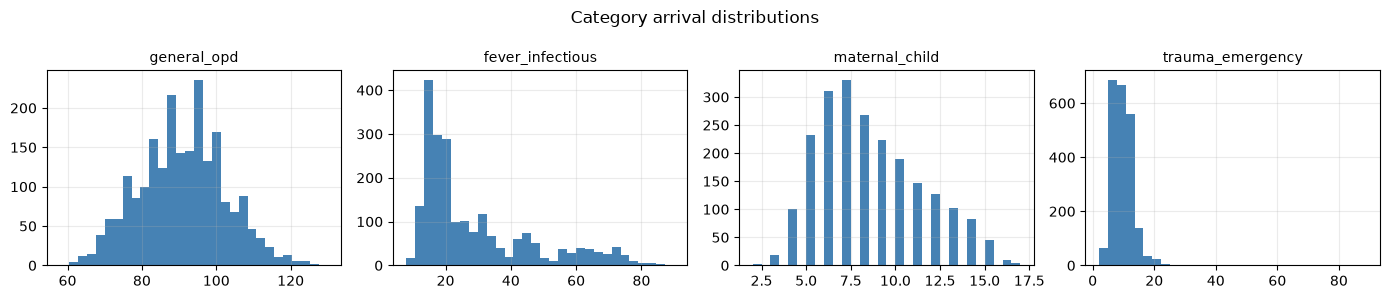

,general_opd_arrivals,fever_infectious_arrivals,maternal_child_arrivals,trauma_emergency_arrivals
count,2192.0,2192.0,2192.0,2192.0
mean,90.8,29.1,8.4,9.6
std,11.6,17.8,2.9,5.1
min,58.0,8.0,2.0,2.0
25%,83.0,16.0,6.0,7.0
50%,91.0,20.5,8.0,9.0
75%,98.0,37.0,10.0,12.0
max,130.0,90.0,17.0,89.0


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, c in zip(axes, CATS):
    ax.hist(df[c], bins=30, color="steelblue")
    ax.set_title(c.replace("_arrivals", ""), fontsize=10)
fig.suptitle("Category arrival distributions"); plt.tight_layout(); plt.show()
df[CATS].describe().round(1)

**Read:** general OPD is roughly symmetric; **fever_infectious is right-skewed**
with a long tail — the monsoon/outbreak surges. No negative or absurd values
(already confirmed by `validate_data.py`). The skew is expected and meaningful.

## 7. Does resource planning follow demand?

The resource columns (Group D) are **outputs** of planning, not model inputs, but
we verify they scale sensibly with demand — this validates the Phase 7 logic.

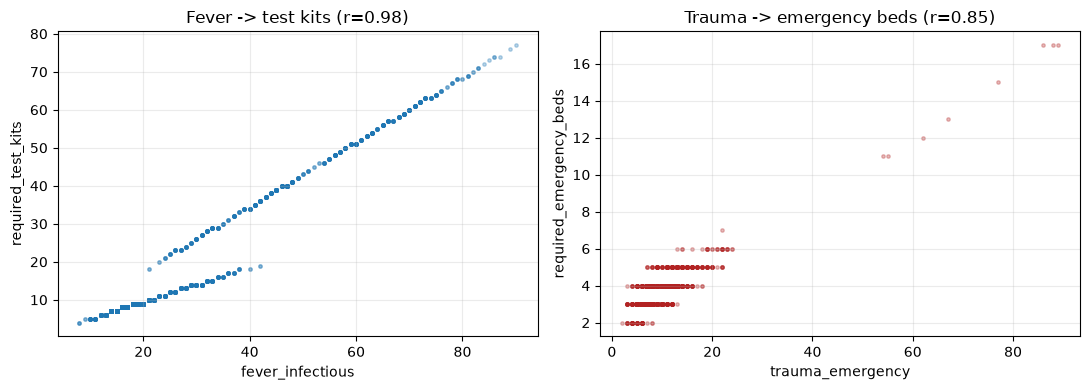

,demand,resource,corr
0,fever_infectious_arrivals,required_diagnostic_test_kits,0.98
1,fever_infectious_arrivals,required_isolation_beds,0.96
2,fever_infectious_arrivals,required_antipyretic_units,1.00
3,trauma_emergency_arrivals,required_emergency_beds,0.85
4,trauma_emergency_arrivals,required_ambulances,0.75
5,expected_admissions,required_general_beds,0.97


In [9]:
pairs = [
    ("fever_infectious_arrivals", "required_diagnostic_test_kits"),
    ("fever_infectious_arrivals", "required_isolation_beds"),
    ("fever_infectious_arrivals", "required_antipyretic_units"),
    ("trauma_emergency_arrivals", "required_emergency_beds"),
    ("trauma_emergency_arrivals", "required_ambulances"),
    ("expected_admissions",       "required_general_beds"),
]
rows = [{"demand": a, "resource": b, "corr": round(df[a].corr(df[b]), 2)} for a, b in pairs]
res_corr = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(df["fever_infectious_arrivals"], df["required_diagnostic_test_kits"], s=6, alpha=0.3)
ax[0].set_xlabel("fever_infectious"); ax[0].set_ylabel("required_test_kits")
ax[0].set_title("Fever -> test kits (r=0.98)")
ax[1].scatter(df["trauma_emergency_arrivals"], df["required_emergency_beds"], s=6, alpha=0.3, color="firebrick")
ax[1].set_xlabel("trauma_emergency"); ax[1].set_ylabel("required_emergency_beds")
ax[1].set_title("Trauma -> emergency beds (r=0.85)")
plt.tight_layout(); plt.show()
res_corr

**Read:** requirements rise with the demand category they serve
(fever → test kits/isolation/antipyretics at r ≈ 0.96-1.00; trauma → emergency
beds/ambulances at r ≈ 0.75-0.85; admissions → general beds r ≈ 0.97). The
resource logic is coherent.

**Data caveats found (documented for later phases):**
- `overflow_patients` is **constant 0** — no signal; Phase 12 overload must be
  computed from required-vs-available + thresholds, not this column.
- `required_obgyn_doctors` and `required_pediatricians` are **constant = 1**
  (fixed minimum staffing) — drop as features where variance is needed.
- `required_oxygen_cylinders` is driven by **Respiratory** outbreaks (mean 10.4
  vs 1.2 baseline), not trauma — design the oxygen formula around respiratory load.

## 8. Leakage-safe feature list (for Phase 6)

The demand model predicts **Group B (patient targets)** and may use **only**
Group A predictors + lag/rolling features. It must **never** use Group C
(current resource state) or Group D (resource-planning outputs) — those are
computed *from* the forecast, so using them would leak the answer.

In [10]:
LEAKAGE_SAFE_FEATURES = [
    # calendar / time
    "day_of_week_num", "week_of_year", "month", "season", "is_weekend",
    "public_holiday", "festival_flag", "weekly_market_day",
    "vaccination_camp_flag", "maternal_clinic_day", "local_event_intensity",
    # weather
    "rainfall_mm", "temperature_max_c", "temperature_min_c", "humidity_pct",
    # outbreak / surveillance signals
    "outbreak_type", "outbreak_severity_0_5", "surveillance_alert", "affected_villages",
    # lag / rolling (past demand only)
    "patients_lag_1", "patients_lag_2", "patients_lag_7", "patients_lag_14",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_14",
]
TARGETS = ["general_opd_arrivals", "fever_infectious_arrivals",
           "maternal_child_arrivals", "trauma_emergency_arrivals",
           "total_patient_arrivals", "expected_admissions"]
EXCLUDED_LEAKAGE = [c for c in df.columns
                    if c.startswith(("required_", "available_", "stock_"))
                    or c in ("resource_shortage_count", "overflow_patients", "emergency_risk_level")]

print(f"{len(LEAKAGE_SAFE_FEATURES)} safe features | {len(TARGETS)} targets | "
      f"{len(EXCLUDED_LEAKAGE)} excluded (leakage) | date is the index key")
assert not (set(LEAKAGE_SAFE_FEATURES) & set(EXCLUDED_LEAKAGE)), "no leakage columns in features"
assert not (set(LEAKAGE_SAFE_FEATURES) & set(TARGETS)), "no targets in features"
print("Leakage checks passed.")

26 safe features | 6 targets | 34 excluded (leakage) | date is the index key
Leakage checks passed.


## Conclusion

The synthetic data behaves like a plausible rural hospital:

- **Strong, learnable seasonality** (monsoon fever surge) and weekly rhythm.
- Every event/weather/outbreak driver correlates with the **clinically correct**
  demand category.
- **Resource requirements scale with demand** (r ≈ 0.75-1.00), validating the
  Phase 7 logic.
- A clean **leakage-safe feature list** is defined for Phase 6.

The forecasting problem is realistic and well-posed. Full write-up:
`docs/EDA_FINDINGS.md`.